# Support Vector Machines (SVM)

## Linear SVM

In [51]:
DEBUG = True #sebug mode, do not use all data since SVM takes too long

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from train_validation_split import splitTrainingValidation
from load_dataset import loadDataSet


SVMPath = './models/SVM'
if not SVMPath in sys.path:
    sys.path.append(SVMPath)

import SVM_linear, SVM_nonlinear

filename = "dataset/trainData.txt"
D, L = loadDataSet(filename, numFeatures=6)
if DEBUG:
    # Use only a subset of the data for debugging
    D = D[:, :100]
    L = L[:100]

(DTR, LTR), (DVAL, LVAL) = splitTrainingValidation(2.0/3.0, D, L)


print(f"DTR shape: {DTR.shape}")
print(f"DVAL shape: {DVAL.shape}")
print(f"LTR shape: {LTR.shape}")
print(f"LVAL shape: {LVAL.shape}")

DTR shape: (6, 66)
DVAL shape: (6, 34)
LTR shape: (66,)
LVAL shape: (34,)


We train and fit linear SVM, using $K = 1.0$ and different values of $C$. We then plot $\text{min DCF}$ and $\text{DCF}$ as functions of $C$.

In [53]:
from joblib import Parallel, delayed #for parallel processing

### 1. SVM, $K = 1.0$, different values of $C$, usual application $\left( \pi_T = 0.1, 1.0, 1.0 \right)$ - **Uncentered data**

In [54]:
def train_single_svm(C_test, K_test, DTR, LTR, DVAL, LVAL, appPriorTrue):
    """
    Trains a single SVM with the given parameters and returns the results.
    This function is a wrapper for the real SVM training function to allow parallel execution.
    """
    print(f"Training SVM with C = {C_test:.5f}...")
    
    #real SVM training function
    bestW, bestB, minDCF, DCF, errorRate, primal, dual, dualitygap = SVM_linear.fit_SVM_Linear_SoftMargin(
        DTR, LTR, DVAL, LVAL, C_test, K_test, appPriorTrue
    )
    
    print(f"Tested SVM_Linear_SoftMargin with C = {C_test}, K = {K_test}, minDCF = {minDCF}, DCF = {DCF}, errorRate = {errorRate}")
    

    return K_test, C_test, minDCF, DCF, errorRate, primal, dual, dualitygap


C_values = np.logspace(-5, 0, 11)
K_test = 1.0  # Fixed kernel parameter
appPriorTrue = 0.1


#parallelize the training of SVMs for different C values
#n_jobs=-1 means using all available CPU cores
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(train_single_svm)(
        C_test_value, K_test, DTR, LTR, DVAL, LVAL, appPriorTrue
    ) for C_test_value in C_values
)


unpacked_results = zip(*results)
K_table, C_table, minDCF_table, DCFs_table, errorRate_table, \
primal_loss_table, dual_loss_table, dualitygap_table = unpacked_results


table_data = []
for i in range(len(K_table)):
    table_data.append([K_table[i], C_table[i], f"{primal_loss_table[i]:.6e}", f"{-dual_loss_table[i]:.6e}", round(dualitygap_table[i], 4), f"{errorRate_table[i] * 100:.2f}%", round(minDCF_table[i], 4), round(DCFs_table[i], 4)])


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0315s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   2 out of  11 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   4 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.0s finished


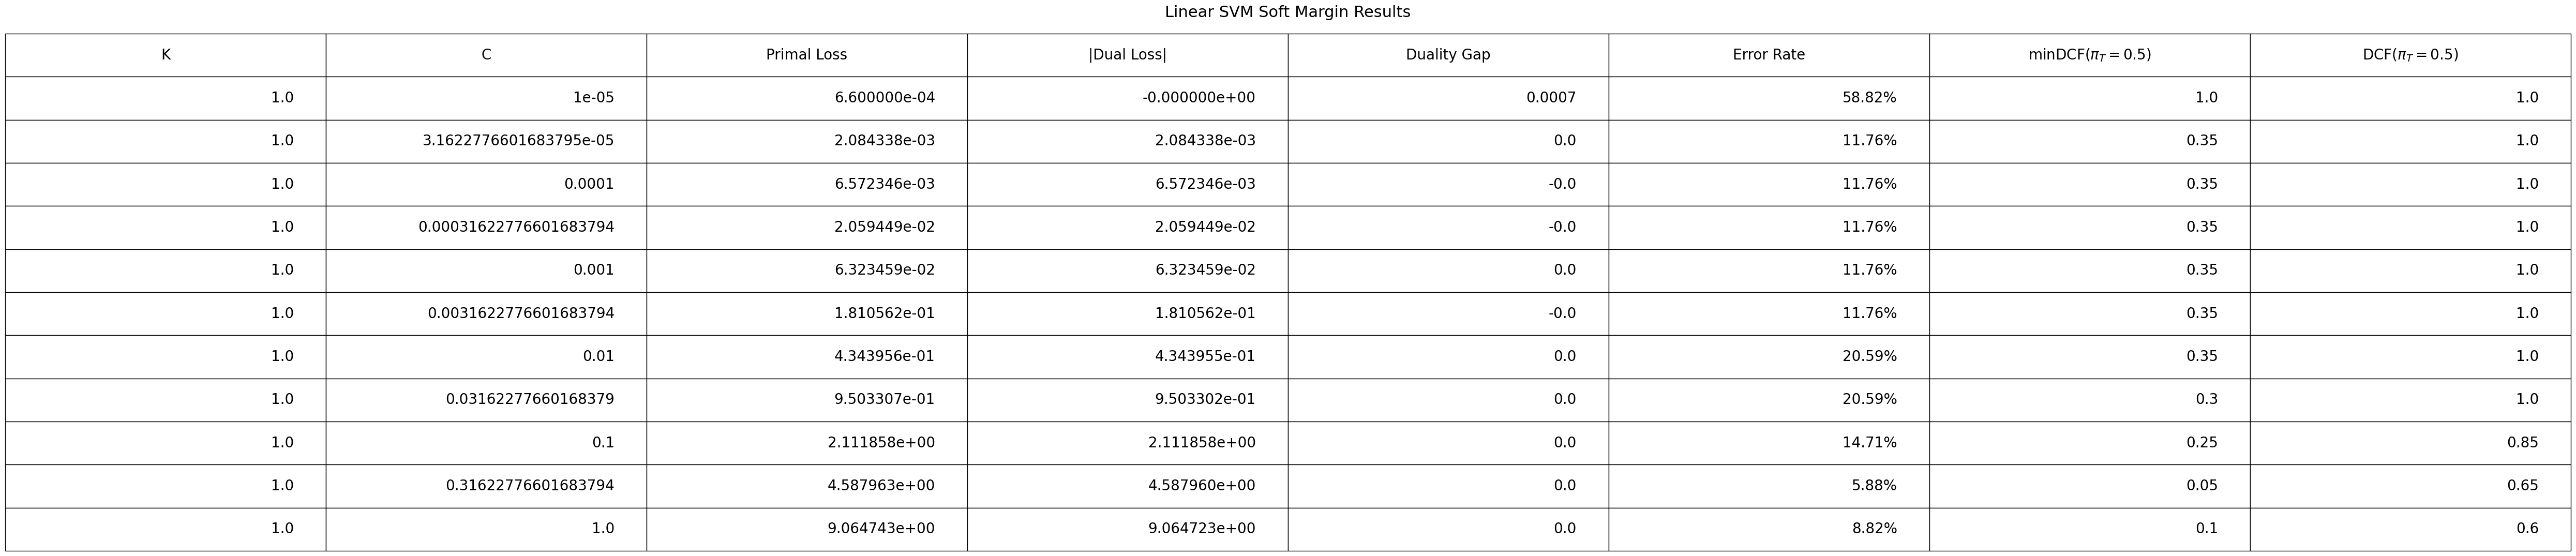

In [55]:
fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=['K', 'C', 'Primal Loss', '|Dual Loss|', 'Duality Gap', 'Error Rate', 'minDCF($\pi_T = 0.5$)', 'DCF($\pi_T = 0.5$)'], loc='center')
table.auto_set_font_size(False)
table.set_fontsize(20)
table.scale(10, 5)
plt.title('Linear SVM Soft Margin Results', fontsize=22, pad=250)
plt.show()

Text(0.5, 1.0, 'minDCF and actDCF vs C')

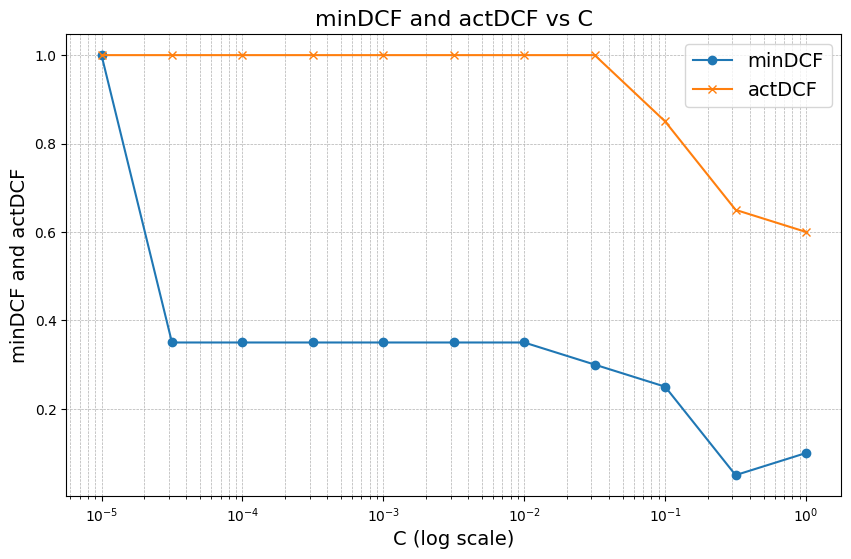

In [ ]:

#plot minDCF, actDCF vs C
plt.figure(figsize=(10, 6))
plt.plot(C_table, minDCF_table, label='minDCF', marker='o')
plt.plot(C_table, DCFs_table, label='actDCF', marker='x')
plt.xscale('log')
plt.xlabel('C (log scale)', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylabel('minDCF and actDCF', fontsize=14)
plt.title('minDCF and actDCF vs C', fontsize=16)

## Kernel (Non Linear) SVM

### 1) Polynomial Kernel $k(\mathbf{x}_1, \mathbf{x}_2) = (\mathbf{x}_1^T \mathbf{x}_2 +c)^d$

We now consider the polynomial kernel. For simplicity, we consider only the kernel with $d = 2$, $c = 1$ (but
better results may be possible with different configurations), and we set $\xi = K^2 = 0$, since the kernel already
implicitly accounts for the bias term (due to $c = 1$). We also consider only the original, **non-centered**
features (again, different pre-processing strategies may lead to better results).

In [57]:
def train_single_svm_kernel(C_test, K_test, DTR, LTR, DVAL, LVAL, appPriorTrue, kernel):
    """
    Trains a single SVM with the given parameters and returns the results.
    This function is a wrapper for the real SVM training function to allow parallel execution.
    """
    print(f"Training SVM with C = {C_test:.5f}...")
    
    #real SVM training function
    bestAlpha_hat, minDCF, DCF, errorRate, primal_loss, dual_loss, dualitygap = SVM_nonlinear.fit_SVM_Kernel_SoftMargin(
        DTR, LTR, DVAL, LVAL, C_test, kernel, K_test, appPriorTrue)
    print(f"Tested SVM_Kernel_SoftMargin with K = {K_test}, minDCF = {minDCF}, DCF = {DCF}, errorRate = {errorRate}")
    
    

    return K_test, C_test, minDCF, DCF, errorRate, primal_loss, dual_loss, dualitygap


C_values = np.logspace(-5, 0, 11)
K_test = 0  # xi = K^2 = 0
appPriorTrue = 0.1


#parallelize the training of SVMs for different C values
#n_jobs=-1 means using all available CPU cores
poly_kernel_2_1 = SVM_nonlinear.get_poly_kernel_function(2.0, 1.0)
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(train_single_svm_kernel)(
        C_test_value, K_test, DTR, LTR, DVAL, LVAL, appPriorTrue, kernel=poly_kernel_2_1
    ) for C_test_value in C_values
)


unpacked_results = zip(*results)
K_table, C_table, minDCF_table, DCFs_table, errorRate_table, \
primal_loss_table, dual_loss_table, dualitygap_table = unpacked_results


table_data = []
for i in range(len(K_table)):
    table_data.append([K_table[i], C_table[i], f"{primal_loss_table[i]:.6e}", f"{-dual_loss_table[i]:.6e}", round(dualitygap_table[i], 4), f"{errorRate_table[i] * 100:.2f}%", round(minDCF_table[i], 4), round(DCFs_table[i], 4)])


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0360s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   2 out of  11 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   4 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   8 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.0s finished


Text(0.5, 1.0, 'minDCF and actDCF vs C')

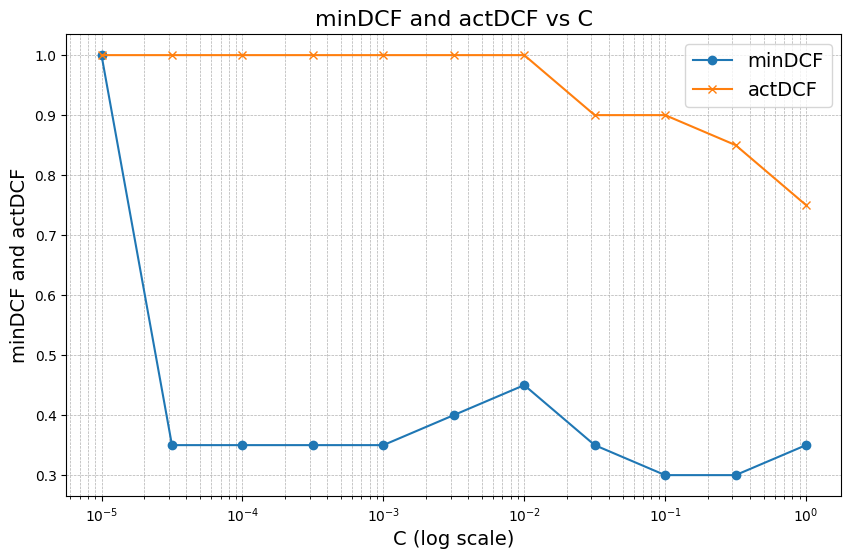

In [58]:

#plot minDCF, actDCF vs C
plt.figure(figsize=(10, 6))
plt.plot(C_table, minDCF_table, label='minDCF', marker='o')
plt.plot(C_table, DCFs_table, label='actDCF', marker='x')
plt.xscale('log')
plt.xlabel('C (log scale)', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylabel('minDCF and actDCF', fontsize=14)
plt.title('minDCF and actDCF vs C', fontsize=16)